# Phase 3: Data Preparation

**CRISP-DM Purpose:** Transform the raw panel into the final modeling-ready matrix.
All cleaning decisions made here; nothing changes in Phase 4.

**Project:** Safehouse Outcome Drivers — Panel Regression  
**Depends on:** Phase 2 (signed off)

**Deliverables this phase:**
1. Transformation decision log
2. Before / after distributions for log-transformed features
3. Scaler stats table (needed for Phase 5 interpretation)
4. Final feature matrix inspection (mean ≈ 0, std ≈ 1 check)
5. Patsy formula strings for both models
6. Panel saved to `data/processed/panel_model_ready.parquet`
7. Scaler stats saved to `data/processed/scaler_stats.csv`

In [31]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    DATA_PROCESSED, PANEL_READY_FILE, SCALER_STATS_FILE,
    OUTCOME_HEALTH, OUTCOME_EDUCATION,
    REGRESSION_FEATURES, REGION_REFERENCE,
)
from src.data_io   import load_panel
from src.features  import build_model_matrix, FEATURES_LOG1P, FEATURES_FILL_ZERO

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("Setup complete. Output dir:", DATA_PROCESSED)

Setup complete. Output dir: C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\safehouse_outcome_drivers\data\processed


---
## 3.1. Transformation Decision Log

All decisions confirmed in the Phase 3 interview (2026-04-09):

| Feature | log1p? | Fill NaN→0? | Z-scored? | Rationale |
|---------|--------|-------------|-----------|----------|
| `sessions_per_resident` | ✅ | — | ✅ | Right-skewed ratio; log compresses tail |
| `visits_per_resident`   | ✅ | — | ✅ | Same |
| `occupancy_rate`        | — | — | ✅ | Bounded ~0–1.2; no skew correction needed |
| `pct_high_risk`         | — | ✅ | ✅ | NaN = no resident record for month → 0% |
| `pct_trafficked`        | — | ✅ | ✅ | Same |
| `pct_special_needs`     | — | ✅ | ✅ | Same |
| `months_since_start`    | — | — | ✅ | Linear time trend; no transform needed |

**Z-scoring rationale:** Standardised coefficients (β in SD units) allow direct magnitude
comparison across features in the Phase 4 coefficient table — answering
"which inputs have the largest partial association with outcomes?"

---
## 3.2. Load Panel and Apply Transformations

In [32]:
panel = load_panel(verbose=True)
df, model_features, scaler_stats = build_model_matrix(panel)

print(f"\nModel features ({len(model_features)}): {model_features}")
print(f"\nScaler stats:")
display(scaler_stats)

[data_io] Raw metrics : 450 rows
[data_io] Dropped 197 NULL-outcome rows (startup gaps + reporting lags + future scaffold). Remaining: 253
[data_io] Building resident time-slice features …
[data_io] Panel ready: 253 rows × 24 columns

Model features (7): ['sessions_per_resident_std', 'visits_per_resident_std', 'occupancy_rate_std', 'pct_high_risk_std', 'pct_trafficked_std', 'pct_special_needs_std', 'months_since_start_std']

Scaler stats:


,feature,log1p_applied,fill_zero,mean_before_std,std_before_std
0,sessions_per_resident,True,False,0.763354,0.333630
1,visits_per_resident,True,False,0.451561,0.247297
2,occupancy_rate,False,False,0.740570,0.234144
3,pct_high_risk,False,True,8.468379,16.454676
4,pct_trafficked,False,True,19.407115,23.334612
5,pct_special_needs,False,True,8.814229,15.007743
6,months_since_start,False,False,23.984190,10.150834


---
## 3.3. Before / After Distributions — Log-Transformed Features

Confirm the log1p transform reduces right skew for `sessions_per_resident`
and `visits_per_resident`.

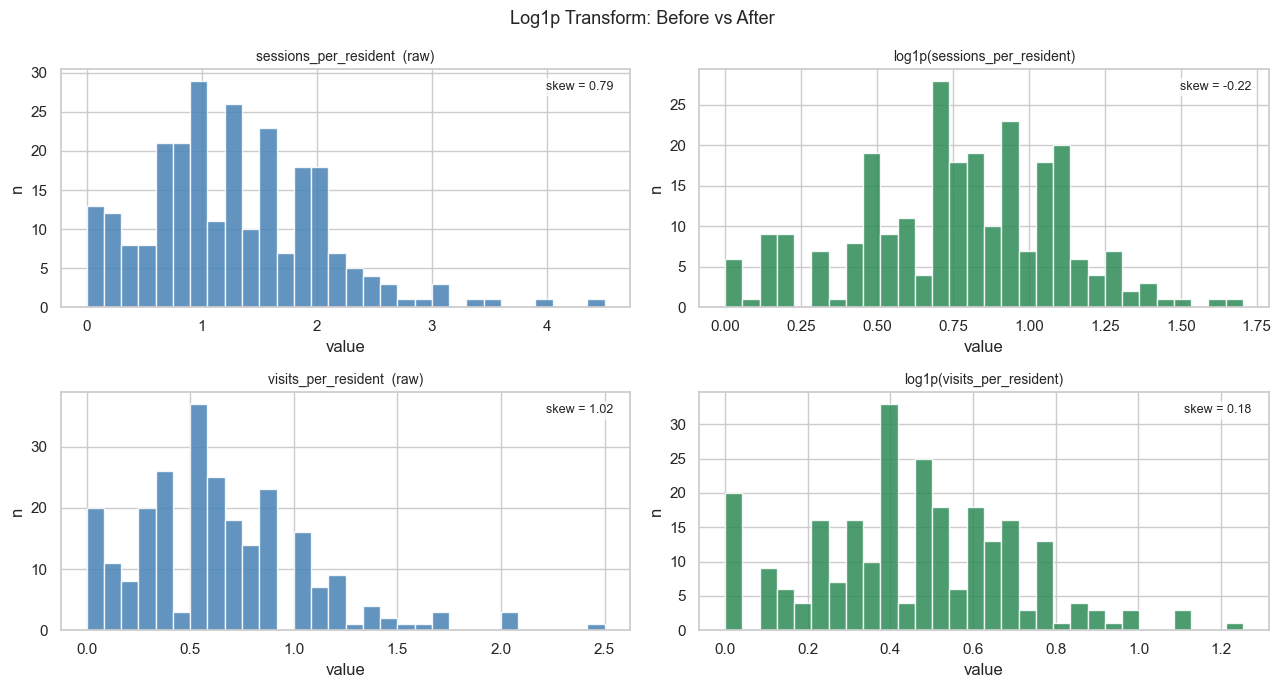

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for row_idx, feat in enumerate(FEATURES_LOG1P):
    raw_col  = panel[feat]
    log_col  = np.log1p(panel[feat])

    ax_raw = axes[row_idx][0]
    ax_log = axes[row_idx][1]

    ax_raw.hist(raw_col.dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax_raw.set_title(f"{feat}  (raw)", fontsize=10)
    ax_raw.set_xlabel("value")
    ax_raw.set_ylabel("n")

    raw_skew = float(raw_col.skew())
    log_skew = float(log_col.skew())

    ax_log.hist(log_col.dropna(), bins=30, color="seagreen", edgecolor="white", alpha=0.85)
    ax_log.set_title(f"log1p({feat})", fontsize=10)
    ax_log.set_xlabel("value")
    ax_log.set_ylabel("n")

    for ax, skew in [(ax_raw, raw_skew), (ax_log, log_skew)]:
        ax.text(
            0.97, 0.95, f"skew = {skew:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )

plt.suptitle("Log1p Transform: Before vs After", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3.4. Final Feature Matrix Inspection

All `_std` columns should have mean ≈ 0 and std ≈ 1.

In [34]:
std_desc = df[model_features].describe().T[["mean", "std", "min", "max"]].round(4)
std_desc["mean≈0"] = std_desc["mean"].abs() < 1e-10
std_desc["std≈1"]  = (std_desc["std"] - 1.0).abs() < 1e-6
print("Standardised feature sanity check:")
display(std_desc)

# Remaining NaN after transforms
nan_counts = df[model_features].isnull().sum()
print(f"\nNaN in model features after transforms: {nan_counts.sum()} total")
if nan_counts.sum() > 0:
    print(nan_counts[nan_counts > 0])

Standardised feature sanity check:


,mean,std,min,max,mean≈0,std≈1
sessions_per_resident_std,0.0,1.0,-2.2880,2.8217,True,True
visits_per_resident_std,0.0,1.0,-1.8260,3.2398,True,True
occupancy_rate_std,-0.0,1.0,-1.7393,2.1757,True,True
pct_high_risk_std,-0.0,1.0,-0.5146,5.5627,True,True
pct_trafficked_std,-0.0,1.0,-0.8317,3.4538,True,True
pct_special_needs_std,0.0,1.0,-0.5873,2.7443,True,True
months_since_start_std,0.0,1.0,-1.9687,2.4644,True,True



NaN in model features after transforms: 0 total


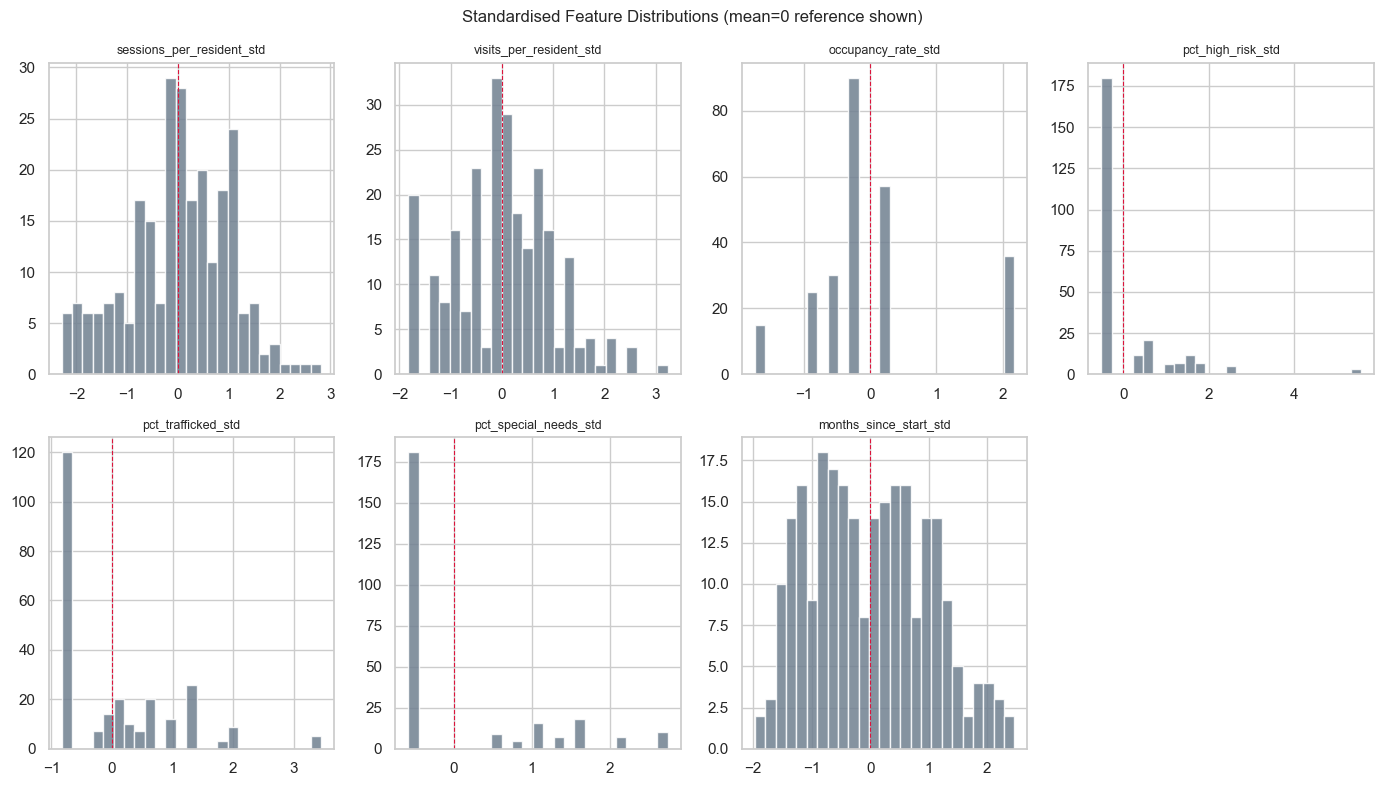

In [35]:
# Distribution of final standardised features
n_cols = 4
n_rows = (len(model_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes_flat = axes.flatten()

for i, feat in enumerate(model_features):
    ax   = axes_flat[i]
    data = df[feat].dropna()
    ax.hist(data, bins=25, color="slategray", edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontsize=9)
    ax.axvline(0, color="crimson", linewidth=0.8, linestyle="--")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Standardised Feature Distributions (mean=0 reference shown)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3.5. Patsy Formula Strings

These are the exact formula strings that Phase 4 will pass to `statsmodels.formula.api.ols`.

- **Fixed effects** encoded via `C(safehouse_id)` — statsmodels drops the lowest
  safehouse ID as the reference automatically.
- **Region dummies** `region_Visayas` and `region_Mindanao` are pre-encoded 0/1
  integers (Luzon = 0 in both, the reference per Phase 1 decision).
- **`-1`** suppresses the intercept column; the FE dummies effectively supply
  per-entity intercepts, so a global intercept is redundant.

> ⚠️ We retain the global intercept (`+1`, the default) rather than `-1`.
> In a within-group FE model via dummies, the intercept represents the baseline
> for the reference safehouse / reference region. Dropping it (`-1`) would force
> all SH intercepts to be expressed as deviations from zero, distorting R².
> Statsmodels handles this correctly with the default intercept.

In [36]:
region_dummies   = [c for c in df.columns if c.startswith("region_")]
rhs_features     = " + ".join(model_features)
rhs_region       = " + ".join(region_dummies)
rhs_fe           = "C(safehouse_id)"
rhs              = f"{rhs_features} + {rhs_region} + {rhs_fe}"

FORMULA_HEALTH    = f"{OUTCOME_HEALTH}    ~ {rhs}"
FORMULA_EDUCATION = f"{OUTCOME_EDUCATION} ~ {rhs}"

print("Model A — Health formula:")
print(f"  {FORMULA_HEALTH}")
print()
print("Model B — Education formula:")
print(f"  {FORMULA_EDUCATION}")
print()
print(f"RHS terms: {len(model_features)} std features  +  {len(region_dummies)} region dummies  +  C(safehouse_id)")

Model A — Health formula:
  avg_health_score    ~ sessions_per_resident_std + visits_per_resident_std + occupancy_rate_std + pct_high_risk_std + pct_trafficked_std + pct_special_needs_std + months_since_start_std + region_Mindanao + region_Visayas + C(safehouse_id)

Model B — Education formula:
  avg_education_progress ~ sessions_per_resident_std + visits_per_resident_std + occupancy_rate_std + pct_high_risk_std + pct_trafficked_std + pct_special_needs_std + months_since_start_std + region_Mindanao + region_Visayas + C(safehouse_id)

RHS terms: 7 std features  +  2 region dummies  +  C(safehouse_id)


---
## 3.6. Save Processed Artifacts

In [37]:
panel_path  = DATA_PROCESSED / PANEL_READY_FILE
scaler_path = DATA_PROCESSED / SCALER_STATS_FILE

df.to_csv(panel_path, index=False)
scaler_stats.to_csv(scaler_path, index=False)

print(f"Saved panel  → {panel_path}")
print(f"Saved scaler → {scaler_path}")
print(f"Panel shape  : {df.shape}")

Saved panel  → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\safehouse_outcome_drivers\data\processed\panel_model_ready.parquet
Saved scaler → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\safehouse_outcome_drivers\data\processed\scaler_stats.csv
Panel shape  : (253, 31)


---
## 3.7. Inclusion / Exclusion Report

Documents every column decision for the modeling matrix.

In [38]:
report = pd.DataFrame([
    # ── Outcomes ──────────────────────────────────────────────────────────────
    {"column": OUTCOME_HEALTH,    "role": "outcome",  "included": True,  "notes": "Model A dependent variable"},
    {"column": OUTCOME_EDUCATION, "role": "outcome",  "included": True,  "notes": "Model B dependent variable"},
    # ── Regression features (standardised) ────────────────────────────────────
    *[
        {"column": f"{f}_std", "role": "predictor", "included": True,
         "notes": ("log1p then z-scored" if f in FEATURES_LOG1P
                   else "fill-0 then z-scored" if f in FEATURES_FILL_ZERO
                   else "z-scored")}
        for f in REGRESSION_FEATURES
    ],
    # ── Region dummies ─────────────────────────────────────────────────────────
    *[
        {"column": c, "role": "region FE", "included": True,
         "notes": f"0/1 dummy; {REGION_REFERENCE} is baseline (not included)"}
        for c in region_dummies
    ],
    # ── Safehouse FE ───────────────────────────────────────────────────────────
    {"column": "safehouse_id",  "role": "entity FE", "included": True,
     "notes": "C(safehouse_id) in formula; SH1 dropped as reference by statsmodels"},
    # ── Excluded ───────────────────────────────────────────────────────────────
    {"column": "incident_count",        "role": "excluded", "included": False,
     "notes": "Reactive event, not a chosen operational input"},
    {"column": "process_recording_count","role": "excluded", "included": False,
     "notes": "Raw count; replaced by sessions_per_resident_std"},
    {"column": "home_visitation_count", "role": "excluded", "included": False,
     "notes": "Raw count; replaced by visits_per_resident_std"},
    {"column": "active_residents",      "role": "excluded", "included": False,
     "notes": "Absorbed into occupancy_rate"},
    {"column": "snapshot_n",            "role": "excluded", "included": False,
     "notes": "Validation column only (Phase 2)"},
    {"column": "notes",                 "role": "excluded", "included": False,
     "notes": "Free-text field"},
])

display(report)

,column,role,included,notes
0,avg_health_score,outcome,True,Model A dependent variable
1,avg_education_progress,outcome,True,Model B dependent variable
2,sessions_per_resident_std,predictor,True,log1p then z-scored
3,visits_per_resident_std,predictor,True,log1p then z-scored
4,occupancy_rate_std,predictor,True,z-scored
5,pct_high_risk_std,predictor,True,fill-0 then z-scored
6,pct_trafficked_std,predictor,True,fill-0 then z-scored
7,pct_special_needs_std,predictor,True,fill-0 then z-scored
8,months_since_start_std,predictor,True,z-scored
9,region_Mindanao,region FE,True,0/1 dummy; Luzon is baseline (not included)


---
## 3.8. Phase Evidence & Assumptions

| Decision | Value | Source |
|----------|-------|--------|
| Coefficient scaling | Z-scored (β in SD units) | User confirmed Phase 3 interview 2026-04-09 |
| Skew correction | log1p for sessions_per_resident, visits_per_resident | User confirmed Phase 3 interview 2026-04-09 |
| pct_* NaN handling | Fill with 0 | User confirmed Phase 3 interview 2026-04-09 |
| Safehouse FE reference | Statsmodels default (lowest ID = SH1) | User confirmed Phase 3 interview 2026-04-09 |
| Region baseline | Luzon (pre-encoded; not in formula) | Phase 1 decision |
| incident_count | Excluded — reactive, not chosen | User confirmed Phase 2 interview 2026-04-09 |

---
## Phase 3 — Sign-off Checklist

Before proceeding to Phase 4 (Modeling), confirm:
- [ ] log1p reduces skew for sessions and visits features (Section 3 plots)
- [ ] All `_std` columns have mean ≈ 0 and std ≈ 1 (Section 4 table)
- [ ] No NaN remaining in model features after transforms (Section 4)
- [ ] Patsy formula strings look correct for both models (Section 5)
- [ ] Inclusion/exclusion report is complete (Section 7)
- [ ] `panel_model_ready.parquet` and `scaler_stats.csv` saved successfully (Section 6)

**Awaiting user sign-off to proceed to Phase 4.**